# Algorithm Comparison — 3×3 Statistical Benchmark Suite

Benchmarks **Proposed (MOEA/D+PSO+SA)** vs. **NSGA-II** vs. **Random Search** across all
9 dataset × hardware combinations using four quality indicators and Wilcoxon rank-sum
tests with Bonferroni correction.

---

## Quality Indicators

| Indicator | Formula | Direction |
|---|---|---|
| **Hypervolume (HV)** | $\lambda\!\bigl(\bigcup_{f \in F}[f, r]\bigr)$, $r=(1.1,1.1)$ | ↑ higher is better |
| **IGD** | $\frac{1}{\|P^*\|}\sum_{p\in P^*}\min_{f\in F}\|p-f\|_2$ | ↓ lower is better |
| **Spacing (S)** | $\sqrt{\frac{1}{N-1}\sum_i(d_i-\bar{d})^2}$ | ↓ lower is better (uniform spread) |
| **Max Spread (MS)** | $\|\max(F)-\min(F)\|_2$ | ↑ higher is better (wider coverage) |

$P^*$ = non-dominated union of **all** algorithm runs across all seeds (unbiased proxy front).  
All metrics are computed in the **normalised** $[0,1]^2$ objective space for fair cross-device comparison.

## Statistical Testing
- **Wilcoxon Rank-Sum** (Mann-Whitney U, two-sided) on HV: Proposed vs. each baseline.
- **Bonferroni correction** over $k = 2 \times 4$ comparisons per combo (2 baselines × 4 metrics).
- **Effect size** $r$ = rank-biserial correlation: $|r|>0.5$ large, $0.3$–$0.5$ medium, $<0.3$ small.


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for _parent in [_cwd, *_cwd.parents]:
    if (_parent / "src").exists() and (_parent / "requirements.txt").exists():
        PROJECT_ROOT = _parent
        break
else:
    raise FileNotFoundError("Unable to locate the repository root for HW-NAS-Memetic.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.data_processing import get_project_root
assert get_project_root() == PROJECT_ROOT

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, proxy_pareto,
    calc_hv, calc_igd, calc_spacing, calc_max_spread,
)
from src.analysis.data_loader import (
    DATASETS, HARDWARE, combo_archive_sets,
    per_seed_all_metrics, best_archs_table,
)
from src.analysis.stats import wilcoxon_ranksum, bonferroni_correction

RESULTS_DIR = PROJECT_ROOT / "results"
OUT_DIR     = RESULTS_DIR / "figures" / "comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

REF      = np.array([1.1, 1.1])
ALGO_NAMES   = ["Proposed", "NSGA-II", "Random Search"]
ALGO_COLORS  = {"Proposed": "#1f77b4", "NSGA-II": "#ff7f0e", "Random Search": "#2ca02c"}
METRICS      = ["hv", "igd", "spacing", "max_spread"]
METRIC_LABEL = {
    "hv":         "HV ↑",
    "igd":        "IGD ↓",
    "spacing":    "Spacing ↓",
    "max_spread": "Max Spread ↑",
}

print("Setup complete.")
print(f"Datasets : {DATASETS}")
print(f"Hardware : {HARDWARE}")
print(f"Algorithms: {ALGO_NAMES}")


Setup complete.
Datasets : ['cifar10', 'cifar100', 'ImageNet16-120']
Hardware : ['edgegpu_latency', 'raspi4_latency', 'eyeriss_latency']
Algorithms: ['Proposed', 'NSGA-II', 'Random Search']


## 1. Data Loading & Per-Seed Metric Computation

For each of the **9 (dataset × hardware)** combos:

1. Load all seed archives for Proposed, NSGA-II, and Random Search.
2. Build an unbiased proxy $P^*$ from the non-dominated union of all algorithms.
3. Normalise the objective space to $[0,1]^2$ using the combined min/max of all points.
4. Compute **HV, IGD, Spacing, Max Spread** for every seed of every algorithm.
5. Run pairwise **Wilcoxon rank-sum** tests (Proposed vs. each baseline) on HV.


In [2]:
# ── 3×3 nested computation loop ───────────────────────────────────────────────
# all_metrics[dataset][hw][algo] = dict with keys "hv","igd","spacing","max_spread"
# stat_results[dataset][hw]      = list of wilcoxon result dicts (vs. each baseline)

all_metrics  = {ds: {hw: {} for hw in HARDWARE} for ds in DATASETS}
stat_results = {ds: {hw: [] for hw in HARDWARE} for ds in DATASETS}

N_TOTAL = len(DATASETS) * len(HARDWARE)
n_done  = 0

for dataset in DATASETS:
    for hw in HARDWARE:
        n_done += 1
        tag = f"[{dataset} × {hw}]"
        print(f"\n{tag}  ({n_done}/{N_TOTAL})")

        # --- 1. load all seed archives ----------------------------------------
        combo = combo_archive_sets(RESULTS_DIR, dataset, hw)
        if not combo:
            print(f"  WARNING: no archives found, skipping.")
            continue

        # --- 2. proxy P* from union of ALL algorithm fronts -------------------
        all_runs = [run for runs in combo.values() for run in runs]
        try:
            p_star = proxy_pareto(all_runs)
        except ValueError as exc:
            print(f"  WARNING: {exc}")
            continue

        # --- 3. normalise using combined min/max of all raw Pareto points ------
        all_raw_pts = np.vstack([
            get_pareto_front(archive_to_points(run))
            for run in all_runs if run
        ])
        f_min = all_raw_pts.min(axis=0)
        f_max = all_raw_pts.max(axis=0)
        denom = np.where(f_max - f_min > 1e-12, f_max - f_min, 1.0)

        def normalise(pts: np.ndarray) -> np.ndarray:
            return (pts - f_min) / denom

        # --- 4. per-seed metrics for every algorithm ---------------------------
        for algo, runs in combo.items():
            m = per_seed_all_metrics(runs, p_star, normalise, REF)
            all_metrics[dataset][hw][algo] = m
            print(f"  {algo:>14s}  HV {m['hv'].mean():.4f}±{m['hv'].std():.4f}"
                  f"  IGD {m['igd'].mean():.4f}±{m['igd'].std():.4f}"
                  f"  S {m['spacing'].mean():.4f}  MS {m['max_spread'].mean():.4f}"
                  f"  (n={len(m['hv'])})")

        # --- 5. Wilcoxon: Proposed vs. each other algo ------------------------
        if "Proposed" not in all_metrics[dataset][hw]:
            continue
        hv_proposed = all_metrics[dataset][hw]["Proposed"]["hv"]
        for baseline in ["NSGA-II", "Random Search"]:
            if baseline not in all_metrics[dataset][hw]:
                continue
            hv_base = all_metrics[dataset][hw][baseline]["hv"]
            res = wilcoxon_ranksum(hv_proposed, hv_base)
            res["dataset"]  = dataset
            res["hw"]       = hw
            res["baseline"] = baseline
            stat_results[dataset][hw].append(res)
            sig = "**" if res["p_value"] < 0.05 else "ns"
            print(f"  Wilcoxon Proposed vs {baseline}: "
                  f"p={res['p_value']:.4f} {sig}  r={res['effect_r']:.3f}")

print("\nAll combos processed.")



[cifar10 × edgegpu_latency]  (1/9)

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

        Proposed  HV 1.0608±0.0007  IGD 0.0074±0.0047  S 0.0229  MS 1.3608  (n=30)
         NSGA-II  HV 1.0612±0.0026  IGD 0.0067±0.0047  S 0.1800  MS 1.3320  (n=30)
   Random Search  HV 1.0598±0.0009  IGD 0.0117±0.0053  S 0.2046  MS 1.3458  (n=30)
  Wilcoxon Proposed vs NSGA-II: p=0.0005 **  r=0.527
  Wilcoxon Proposed vs Random Search: p=0.0001 **  r=-0.582

[cifar10 × raspi4_latency]  (2/9)
        Proposed  HV 1.1633±0.0010  IGD 0.0090±0.0034  S 0.0274  MS 1.2266  (n=30)
         NSGA-II  HV 1.1660±0.0006  IGD 0.0038±0.0024  S 0.1576  MS 1.2914  (n=30)
   Random Search  HV 1.1643±0.0007  IGD 0.0077±0.0034  S 0.1583  MS 1.2320  (n=30)
  Wilcoxon Proposed vs NSGA-II: p=0.0000 **  r=0.971
  Wilcoxon Proposed vs Random Search: p=0.0001 **  r=0.578

## 2. 3×3 Box Plot Grids — All Quality Indicators

One 3×3 grid is produced for **each of the four quality indicators** (HV, IGD, Spacing, Max Spread).
Each panel shows the distribution across 30 seeds for all three algorithms in one
(dataset × hardware) combination. Boxes span the IQR; whiskers extend to 1.5×IQR;
individual outlier seeds are plotted as dots.

Wilcoxon rank-sum significance bars (Proposed vs. each baseline) are shown above each panel:
`*` = significant at α = 0.05 (uncorrected per panel); `ns` = not significant.

| Metric | Direction |
|---|---|
| **HV** | ↑ higher is better |
| **IGD** | ↓ lower is better |
| **Spacing** | ↓ lower is better (uniform front) |
| **Max Spread** | ↑ higher is better (wider coverage) |


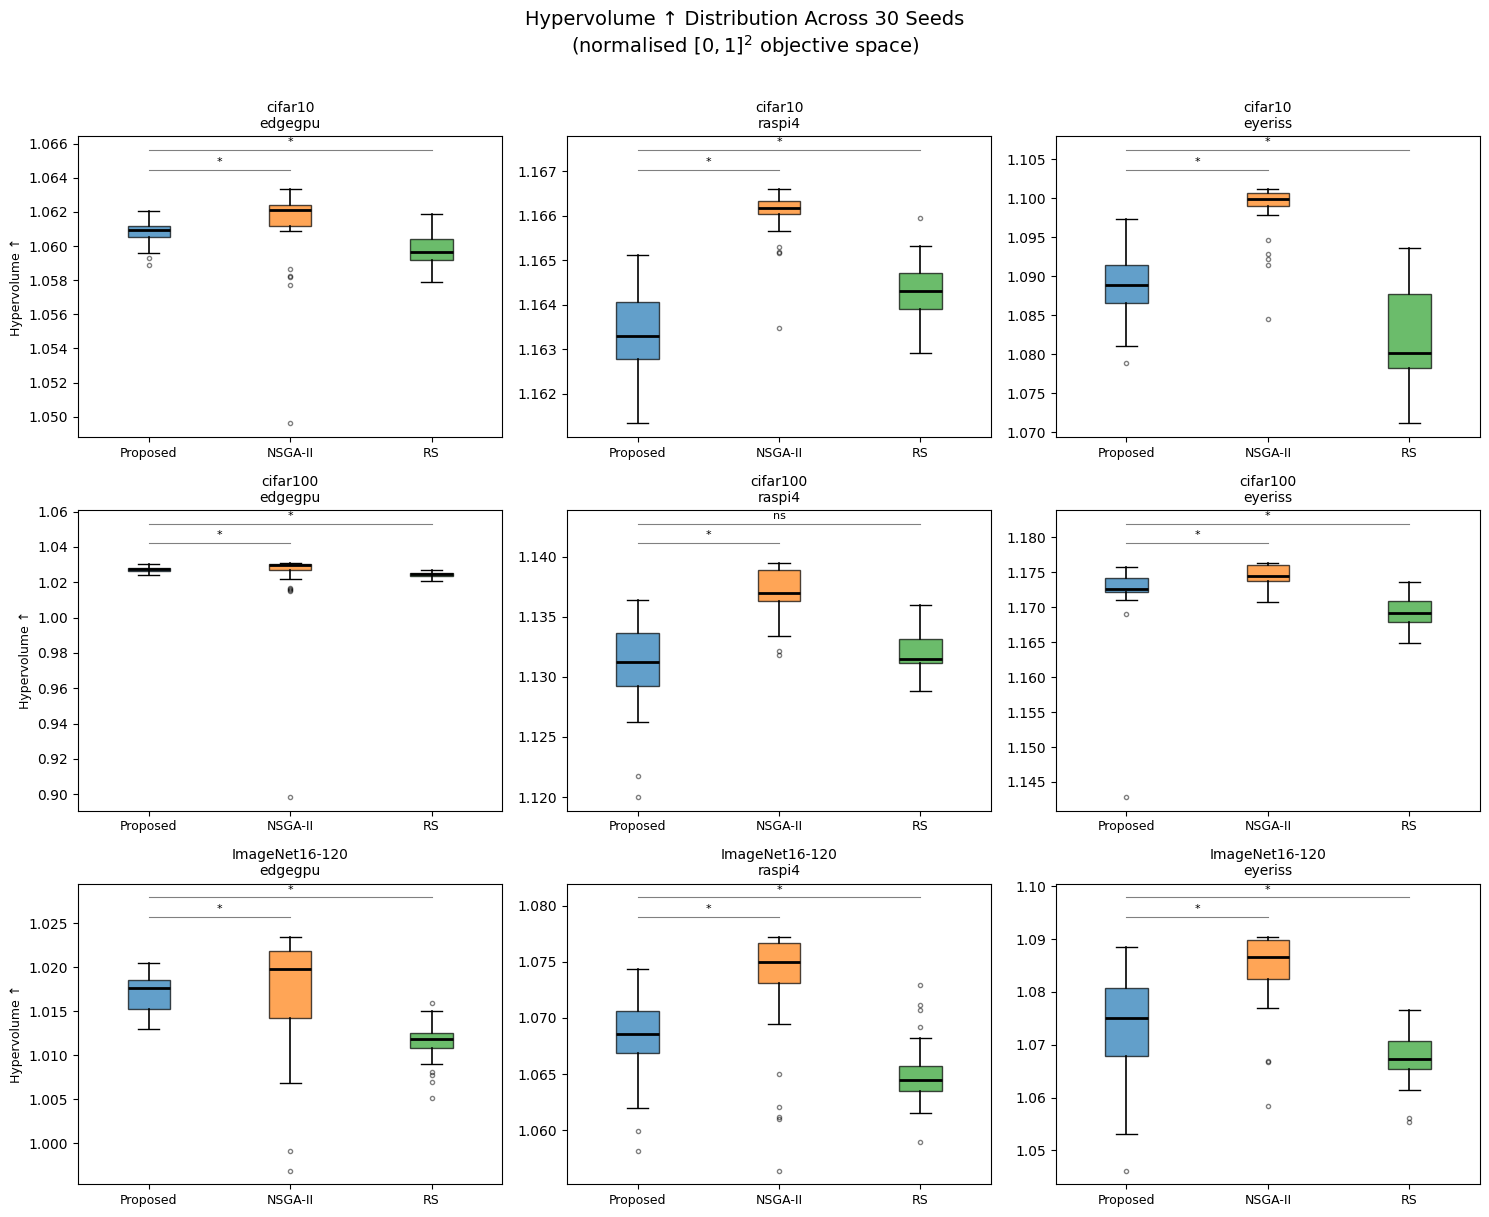

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/comparison/hv_boxplot_3x3.pdf


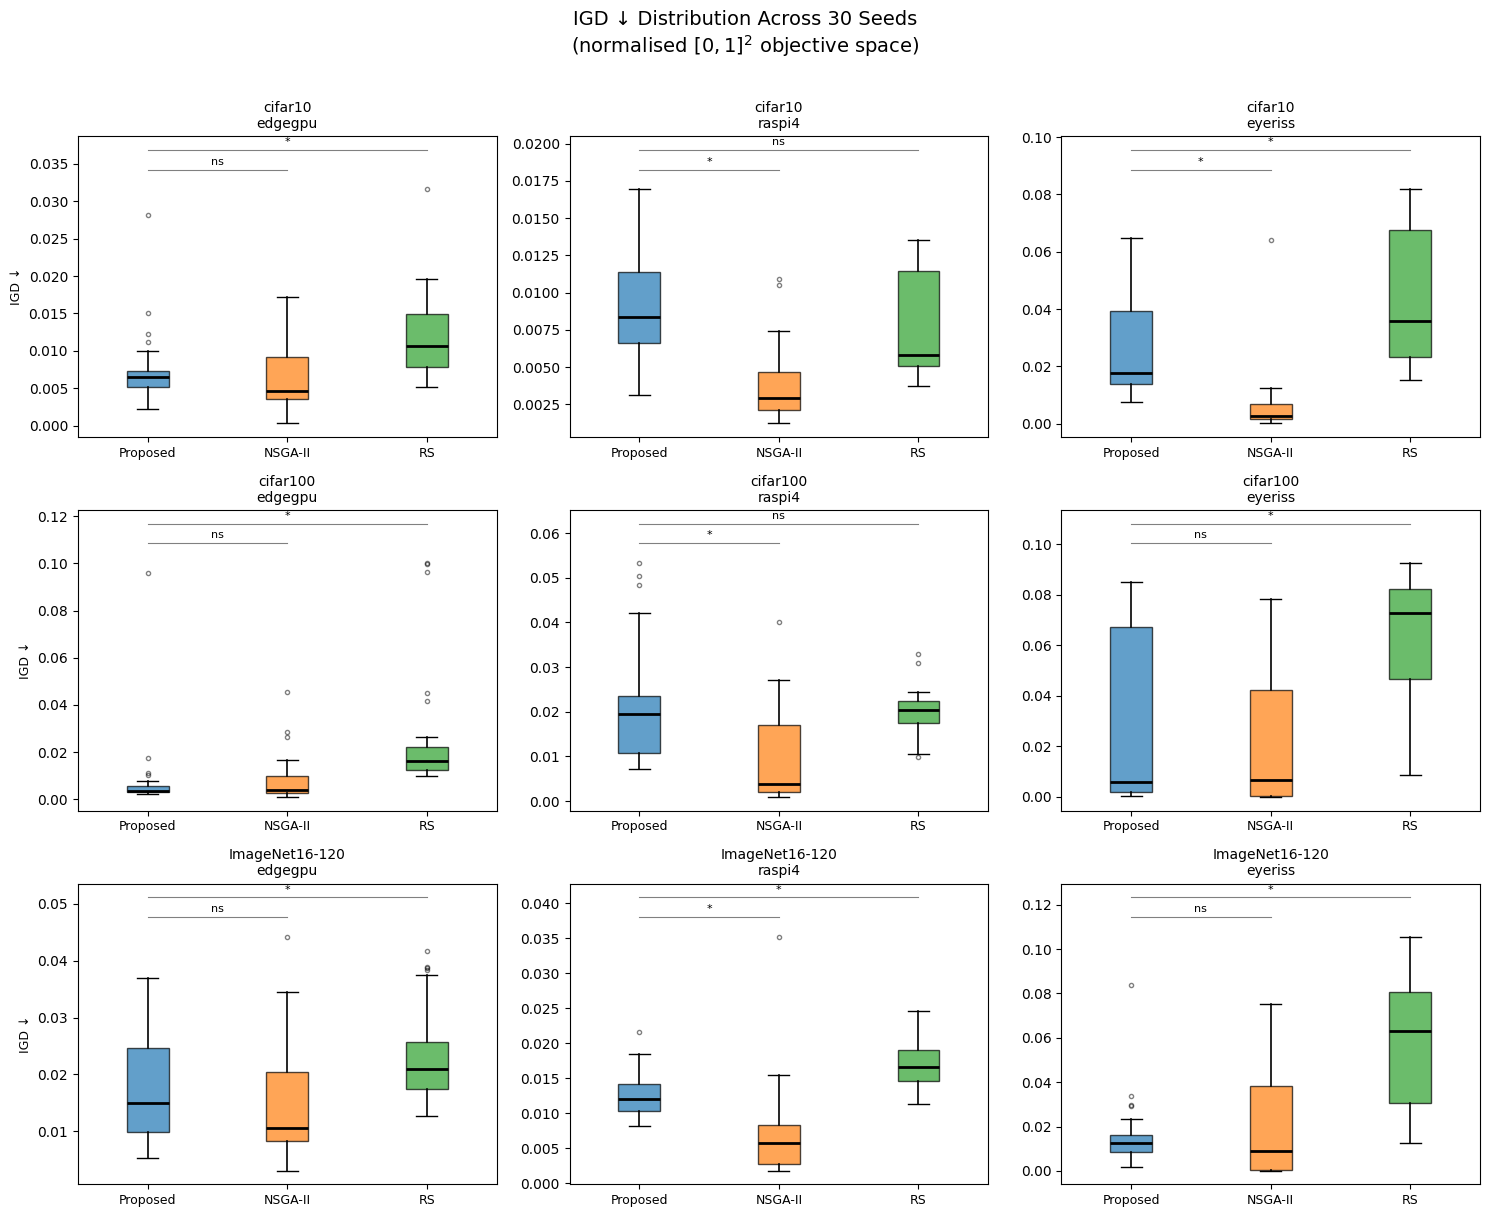

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/comparison/igd_boxplot_3x3.pdf


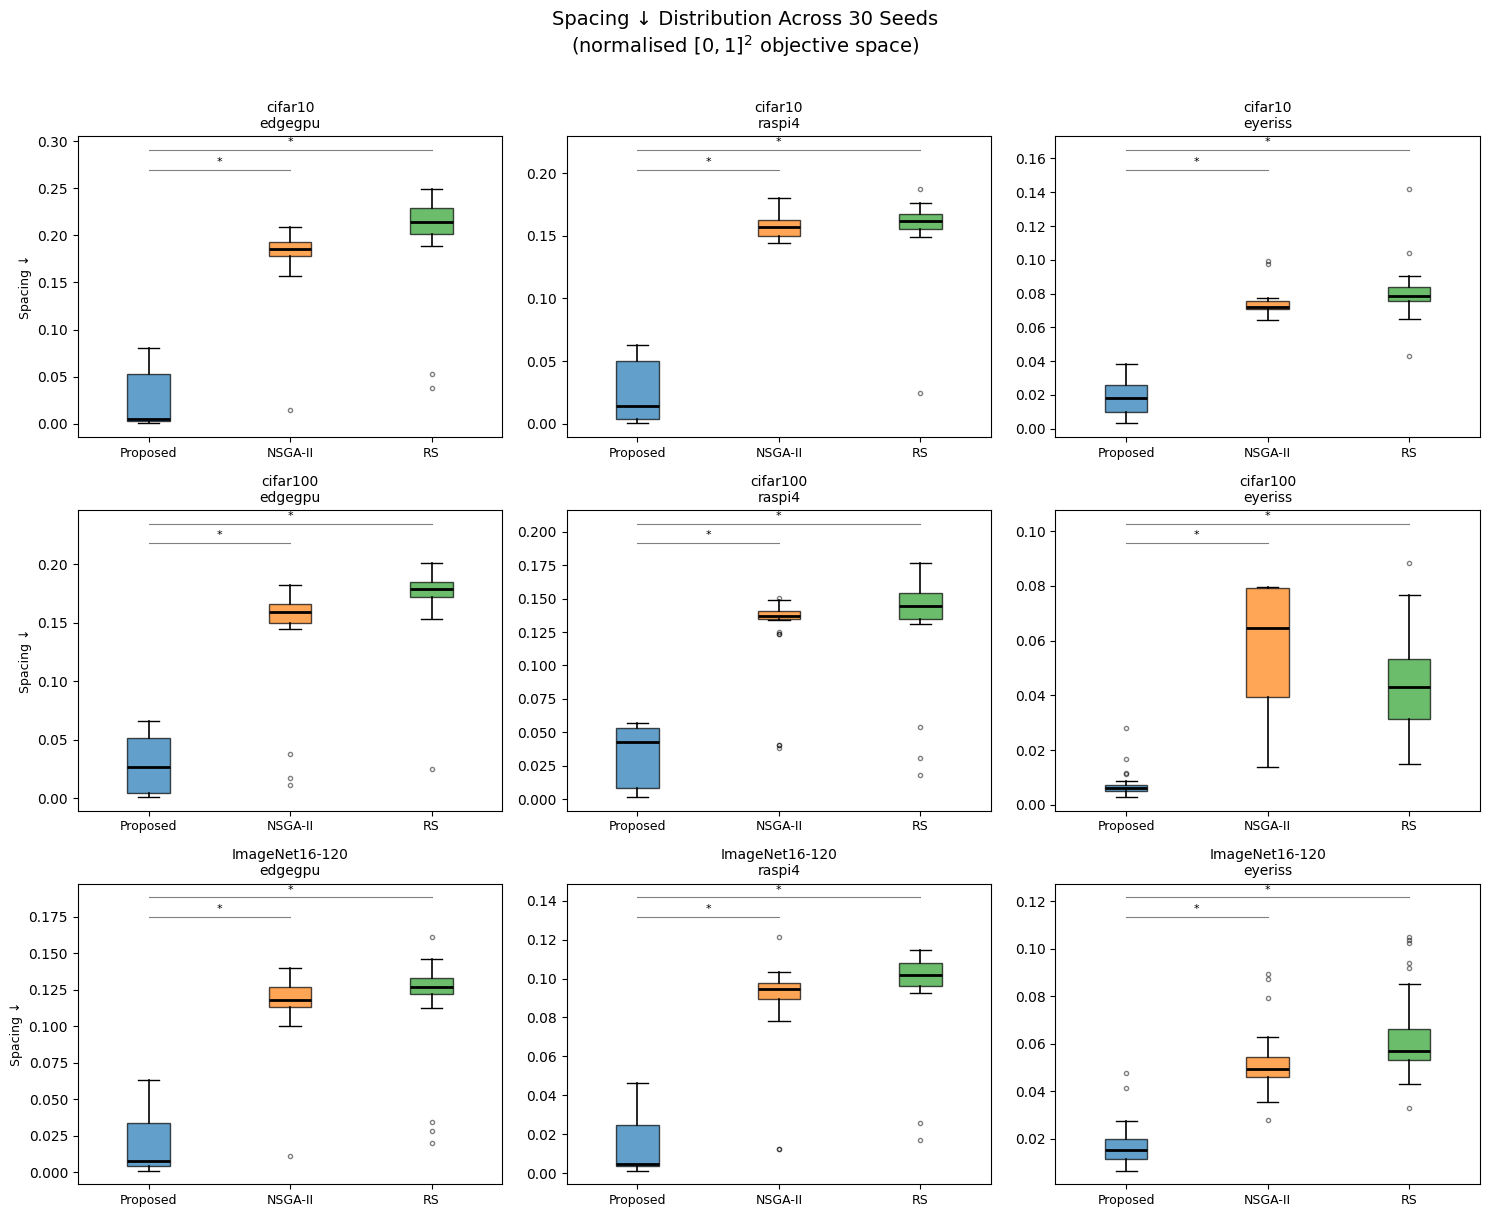

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/comparison/spacing_boxplot_3x3.pdf


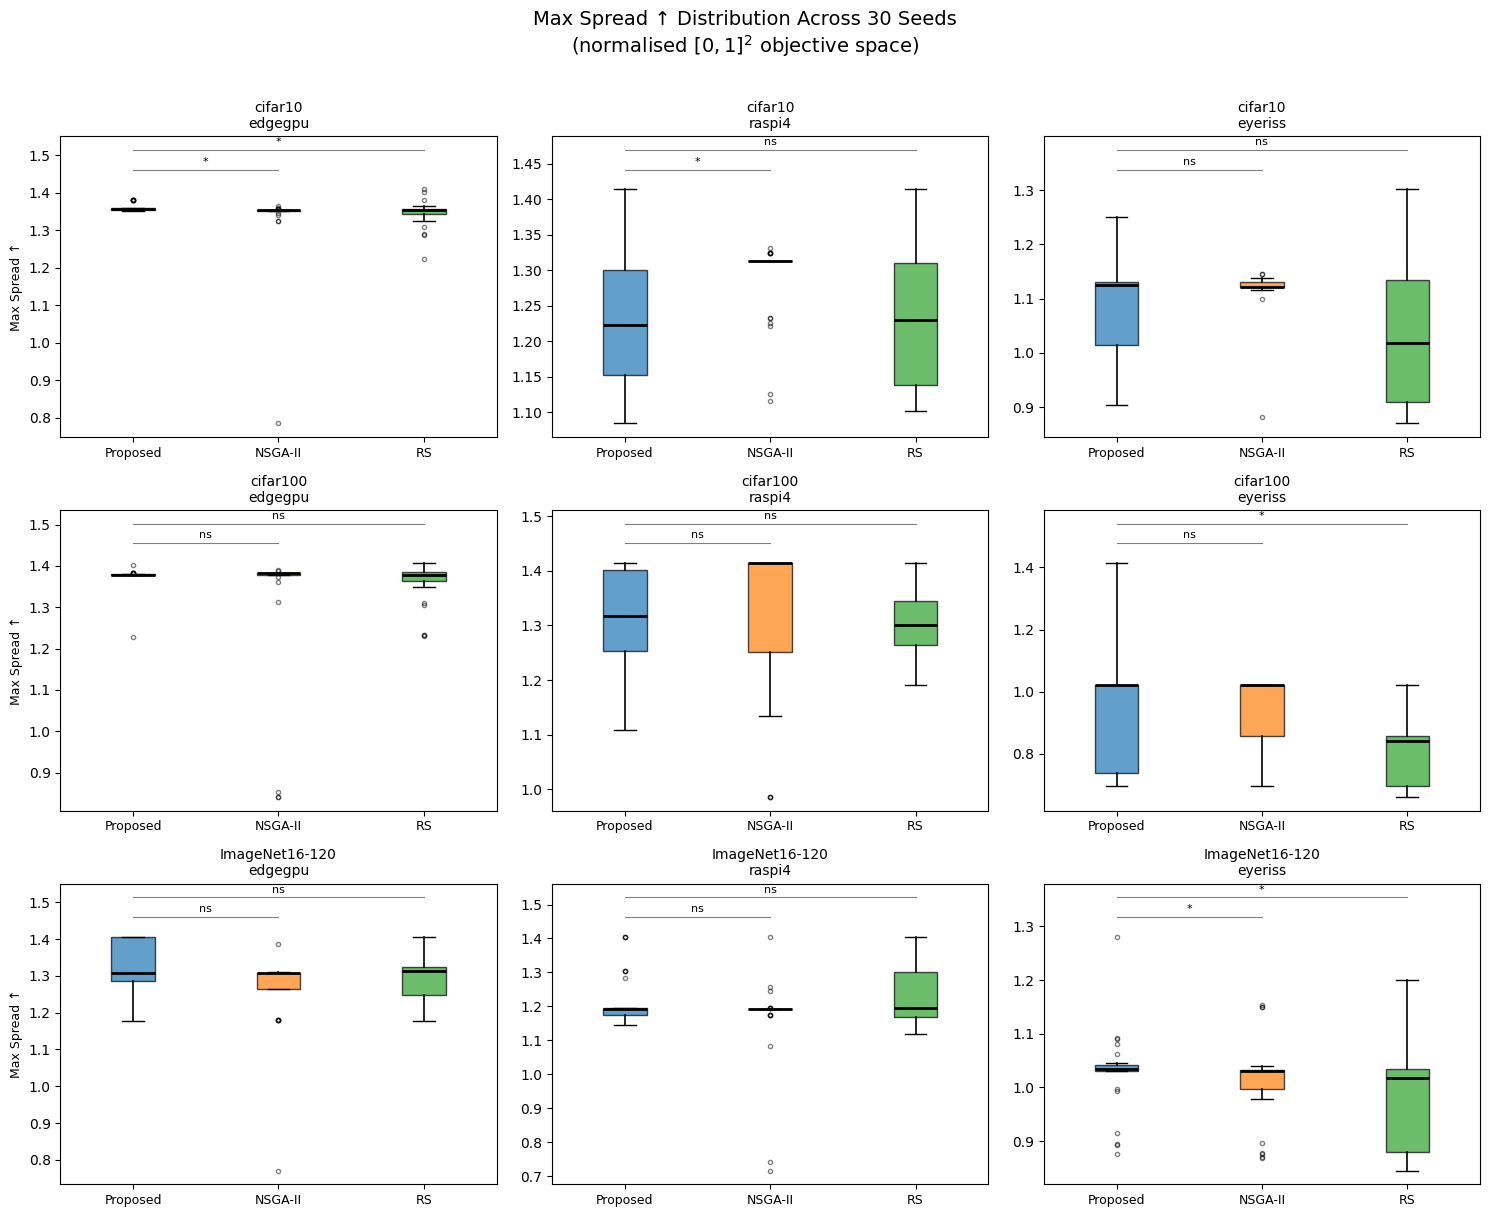

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/comparison/max_spread_boxplot_3x3.pdf


In [3]:
# ── 3×3 box plot grids for every quality indicator ───────────────────────────
# One figure per metric; each panel = one (dataset × hardware) combo.
# Wilcoxon rank-sum tests (Proposed vs. each baseline) are computed per metric
# and displayed as significance bars above each panel.

from scipy.stats import mannwhitneyu as _mwu

ALGO_SHORT = {"Proposed": "Proposed", "NSGA-II": "NSGA-II", "Random Search": "RS"}

# Direction label and "better" direction for each metric
METRIC_META = {
    "hv":         ("Hypervolume ↑",  "higher"),
    "igd":        ("IGD ↓",          "lower"),
    "spacing":    ("Spacing ↓",      "lower"),
    "max_spread": ("Max Spread ↑",   "higher"),
}
METRIC_FNAME = {
    "hv":         "hv_boxplot_3x3.pdf",
    "igd":        "igd_boxplot_3x3.pdf",
    "spacing":    "spacing_boxplot_3x3.pdf",
    "max_spread": "max_spread_boxplot_3x3.pdf",
}

for metric in METRICS:
    ylabel, _ = METRIC_META[metric]

    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharey=False)
    fig.suptitle(
        f"{ylabel} Distribution Across 30 Seeds\n(normalised $[0,1]^2$ objective space)",
        fontsize=14, y=1.01,
    )

    for r, dataset in enumerate(DATASETS):
        for c, hw in enumerate(HARDWARE):
            ax = axes[r][c]
            combo = all_metrics[dataset][hw]
            if not combo:
                ax.set_visible(False)
                continue

            data   = [combo[a][metric] for a in ALGO_NAMES if a in combo]
            labels = [ALGO_SHORT[a]    for a in ALGO_NAMES if a in combo]
            colors = [ALGO_COLORS[a]   for a in ALGO_NAMES if a in combo]
            algos  = [a                for a in ALGO_NAMES if a in combo]

            bp = ax.boxplot(
                data, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=3, alpha=0.5),
            )
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)

            # ── Wilcoxon significance bars (Proposed vs. each baseline) ───────
            if "Proposed" in algos:
                prop_data = combo["Proposed"][metric]
                y_max  = max(d.max() for d in data) if data else 1.0
                y_min  = ax.get_ylim()[0]
                y_step = max((y_max - y_min) * 0.08, 1e-9)

                prop_pos = algos.index("Proposed") + 1   # 1-based boxplot position
                bar_i = 0
                for baseline in ["NSGA-II", "Random Search"]:
                    if baseline not in algos:
                        continue
                    base_data  = combo[baseline][metric]
                    base_pos   = algos.index(baseline) + 1
                    try:
                        _, p_val = _mwu(prop_data, base_data, alternative="two-sided")
                    except ValueError:
                        p_val = 1.0
                    sig_label = "*" if p_val < 0.05 else "ns"
                    y_bar = y_max + y_step * (bar_i + 1)
                    x1, x2 = sorted([prop_pos, base_pos])
                    ax.plot([x1, x2], [y_bar, y_bar], color="gray", linewidth=0.8)
                    ax.text(
                        (x1 + x2) / 2, y_bar + y_step * 0.15, sig_label,
                        ha="center", va="bottom", fontsize=8,
                    )
                    bar_i += 1

            ax.set_xticks(range(1, len(labels) + 1))
            ax.set_xticklabels(labels, fontsize=9)
            ax.set_title(f"{dataset}\n{hw.replace('_latency', '')}", fontsize=10)
            if c == 0:
                ax.set_ylabel(ylabel, fontsize=9)

    plt.tight_layout()
    save_path = OUT_DIR / METRIC_FNAME[metric]
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


## 3. Master Results Table

Mean ± standard deviation for all four quality indicators across all 9 combos.

**Colour legend:**
- 🟢 **Green** — numerically best value per (row × metric)
- 🟡 **Amber** — Proposed is statistically superior (Bonferroni-corrected HV *p* < 0.05), even when the point estimate is not the highest/lowest
- 🩵 **Teal** — both numerically best *and* statistically significant
- 🔵 **Blue columns** — **Spacing ★**, the strongest evidence metric (uniform distribution of the Pareto front); best cell gets darker blue

p-values are Bonferroni-corrected Wilcoxon rank-sum tests on HV; values marked `*` are significant at α = 0.05.


In [4]:
# ── Master results table ──────────────────────────────────────────────────────
# Colour scheme:
#   🟢 green  (#dff0d8) — numerically best per (row × metric)
#   🟡 amber  (#fff9c4) — Proposed statistically superior on HV (Bonferroni p < 0.05),
#                         even when its point estimate is not the best
#   🩵 teal   (#b2dfdb) — BOTH conditions simultaneously
#   🔵 blue            — ALL Spacing ★ cells; best Spacing gets darker blue (#90caf9) + bold
#   red bold           — significant p-value columns (ends with *)

HIGHER_BETTER = {"hv", "max_spread"}

# ── 1. Bonferroni p-value lookup for HV ───────────────────────────────────────
_hv_flat = [
    (ds, hw, res)
    for ds in DATASETS
    for hw in HARDWARE
    for res in stat_results[ds][hw]
]
if _hv_flat:
    _p_raw  = [res["p_value"] for *_, res in _hv_flat]
    _p_corr = bonferroni_correction(_p_raw)
    p_lookup = {
        (ds, hw, res["baseline"]): p_adj
        for (ds, hw, res), p_adj in zip(_hv_flat, _p_corr)
    }
else:
    p_lookup = {}

# ── 2. Raw numeric means/stds ─────────────────────────────────────────────────
rows = []
for dataset in DATASETS:
    for hw in HARDWARE:
        combo = all_metrics[dataset][hw]
        if not combo:
            continue
        row = {"Dataset": dataset, "Hardware": hw.replace("_latency", "")}
        for metric in METRICS:
            for algo in ALGO_NAMES:
                if algo not in combo:
                    row[(metric, algo)] = np.nan
                else:
                    vals = combo[algo][metric]
                    row[(metric, algo)] = (vals.mean(), vals.std())
        rows.append(row)

df_raw = pd.DataFrame(rows).set_index(["Dataset", "Hardware"])

# Spacing labelled with ★ to flag it as the key evidence metric
_DISPLAY_LABELS = {
    "hv":         "HV ↑",
    "igd":        "IGD ↓",
    "spacing":    "Spacing ↓ ★",
    "max_spread": "Max Spread ↑",
}

# ── 3. Format "mean ± std" strings ────────────────────────────────────────────
df_display = pd.DataFrame(index=df_raw.index)
for metric in METRICS:
    lbl = _DISPLAY_LABELS[metric]
    for algo in ALGO_NAMES:
        df_display[(lbl, algo)] = df_raw[(metric, algo)].apply(
            lambda v: f"{v[0]:.4f} ± {v[1]:.4f}"
            if isinstance(v, tuple) and not np.isnan(v[0]) else "—"
        )

# ── 4. Append Bonferroni p-value columns ──────────────────────────────────────
for baseline, label_short in [("NSGA-II", "vs NSGA-II"), ("Random Search", "vs RS")]:
    vals_col = []
    for dataset, hw_short in df_display.index:
        key = (dataset, hw_short + "_latency", baseline)
        p = p_lookup.get(key, np.nan)
        vals_col.append("—" if np.isnan(p) else f"{p:.4f}{'*' if p < 0.05 else ''}")
    df_display[(f"HV p ({label_short})", "Bonferroni†")] = vals_col

df_display.columns = pd.MultiIndex.from_tuples(df_display.columns)

# ── 5. Track is_best and is_sig per cell ──────────────────────────────────────
df_is_best = pd.DataFrame(False, index=df_display.index, columns=df_display.columns)
df_is_sig  = pd.DataFrame(False, index=df_display.index, columns=df_display.columns)

for metric in METRICS:
    lbl = _DISPLAY_LABELS[metric]
    for idx in df_display.index:
        vals_raw = {}
        for algo in ALGO_NAMES:
            try:
                txt = df_display.loc[idx, (lbl, algo)]
                v = float(txt.split("±")[0].strip())
                vals_raw[algo] = v
            except (ValueError, KeyError):
                pass
        if not vals_raw:
            continue
        best_algo = (max(vals_raw, key=vals_raw.__getitem__) if metric in HIGHER_BETTER
                     else min(vals_raw, key=vals_raw.__getitem__))
        df_is_best.loc[idx, (lbl, best_algo)] = True

# Mark Proposed HV as "sig" wherever Bonferroni-corrected p < 0.05 vs any baseline
hv_lbl = _DISPLAY_LABELS["hv"]
for idx in df_display.index:
    dataset, hw_short = idx
    hw_full = hw_short + "_latency"
    p_min = min(
        p_lookup.get((dataset, hw_full, bl), 1.0)
        for bl in ["NSGA-II", "Random Search"]
    )
    if p_min < 0.05:
        df_is_sig.loc[idx, (hv_lbl, "Proposed")] = True

# ── 6. Per-cell styling function ──────────────────────────────────────────────
def _style_matrix(data):
    result = pd.DataFrame("", index=data.index, columns=data.columns)
    for idx in data.index:
        for col in data.columns:
            group      = col[0] if isinstance(col, tuple) else ""
            is_pval    = "HV p" in str(group)
            is_spacing = "Spacing" in str(group)
            is_best    = bool(df_is_best.loc[idx, col])
            is_sig     = bool(df_is_sig.loc[idx, col])

            if is_pval:
                cell_val = str(data.loc[idx, col])
                if cell_val.endswith("*"):
                    result.loc[idx, col] = "color: #c62828; font-weight: bold"
            elif is_spacing:
                if is_best:
                    result.loc[idx, col] = "font-weight: bold; background-color: #90caf9"
                else:
                    result.loc[idx, col] = "background-color: #e3f2fd"
            elif is_best and is_sig:
                result.loc[idx, col] = "font-weight: bold; background-color: #b2dfdb"
            elif is_best:
                result.loc[idx, col] = "font-weight: bold; background-color: #dff0d8"
            elif is_sig:
                result.loc[idx, col] = "font-weight: bold; background-color: #fff9c4"
    return result

styled = df_display.style.apply(_style_matrix, axis=None)

print("Legend:  🟢 green = numerically best  |  🟡 amber = statistically superior Proposed (HV p < 0.05)")
print("         🩵 teal  = best + significant |  🔵 blue  = Spacing ★ (key evidence; best = darker blue)")
print("         red p*  = Bonferroni-corrected Wilcoxon rank-sum significant at α = 0.05\n")
display(styled)

csv_path = RESULTS_DIR / "reports" / "comparison_master_table.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
df_display.to_csv(csv_path)
print(f"\nSaved CSV: {csv_path}")


Legend:  🟢 green = numerically best  |  🟡 amber = statistically superior Proposed (HV p < 0.05)
         🩵 teal  = best + significant |  🔵 blue  = Spacing ★ (key evidence; best = darker blue)
         red p*  = Bonferroni-corrected Wilcoxon rank-sum significant at α = 0.05




Saved CSV: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/reports/comparison_master_table.csv


In [5]:
# ── Wilcoxon significance summary with Bonferroni correction ─────────────────
# Collect all p-values, then apply correction

flat_results: list[dict] = []
for dataset in DATASETS:
    for hw in HARDWARE:
        flat_results.extend(stat_results[dataset][hw])

if flat_results:
    p_values = [r["p_value"] for r in flat_results]
    corrected = bonferroni_correction(p_values)

    table_rows = []
    for r, p_adj in zip(flat_results, corrected):
        table_rows.append({
            "Dataset":        r["dataset"],
            "Hardware":       r["hw"].replace("_latency", ""),
            "vs. Baseline":   r["baseline"],
            "U statistic":    f"{r['U_stat']:.0f}",
            "p (raw)":        f"{r['p_value']:.4f}",
            "p (Bonferroni)": f"{p_adj:.4f}",
            "Effect r":       f"{r['effect_r']:.3f}",
            "Significant":    "Yes *" if p_adj < 0.05 else "No",
        })

    df_stat = pd.DataFrame(table_rows)
    print("Pairwise Wilcoxon Tests (Proposed HV vs. baselines) with Bonferroni correction:\n")
    display(df_stat.set_index(["Dataset", "Hardware", "vs. Baseline"]))

    n_sig = sum(1 for p in corrected if p < 0.05)
    print(f"\nSignificant after Bonferroni: {n_sig} / {len(corrected)}")
else:
    print("No statistical test results available.")


Pairwise Wilcoxon Tests (Proposed HV vs. baselines) with Bonferroni correction:



U statistic p (raw) p (Bonferroni)  \
Dataset        Hardware vs. Baseline                                       
cifar10        edgegpu  NSGA-II               213  0.0005         0.0085   
                        Random Search         712  0.0001         0.0020   
               raspi4   NSGA-II                13  0.0000         0.0000   
                        Random Search         190  0.0001         0.0022   
               eyeriss  NSGA-II                47  0.0000         0.0000   
                        Random Search         721  0.0001         0.0011   
cifar100       edgegpu  NSGA-II               263  0.0058         0.1049   
                        Random Search         823  0.0000         0.0000   
               raspi4   NSGA-II                49  0.0000         0.0000   
                        Random Search         408  0.5395         1.0000   
               eyeriss  NSGA-II               222  0.0008         0.0138   
                        Random Search         794  0.0000         0.0000   
ImageNet16-120 edgegpu  NSGA-II               286  0.0156         0.2815   
                        Random Search         864  0.0000         0.0000   
               raspi4   NSGA-II               161  0.0000         0.0004   
                        Random Search         673  0.0010         0.0181   
               eyeriss  NSGA-II               134  0.0000         0.0001   
                        Random Search         658  0.0022         0.0388   

                                      Effect r Significant  
Dataset        Hardware vs. Baseline                        
cifar10        edgegpu  NSGA-II          0.527       Yes *  
                        Random Search   -0.582       Yes *  
               raspi4   NSGA-II          0.971       Yes *  
                        Random Search    0.578       Yes *  
               eyeriss  NSGA-II          0.896       Yes *  
                        Random Search   -0.602       Yes *  
cifar100       edgegpu  NSGA-II          0.416          No  
                        Random Search   -0.829       Yes *  
               raspi4   NSGA-II          0.891       Yes *  
                        Random Search    0.093          No  
               eyeriss  NSGA-II          0.507       Yes *  
                        Random Search   -0.764       Yes *  
ImageNet16-120 edgegpu  NSGA-II          0.364          No  
                        Random Search   -0.920       Yes *  
               raspi4   NSGA-II          0.642       Yes *  
                        Random Search   -0.496       Yes *  
               eyeriss  NSGA-II          0.702       Yes *  
                        Random Search   -0.462       Yes *


Significant after Bonferroni: 15 / 18


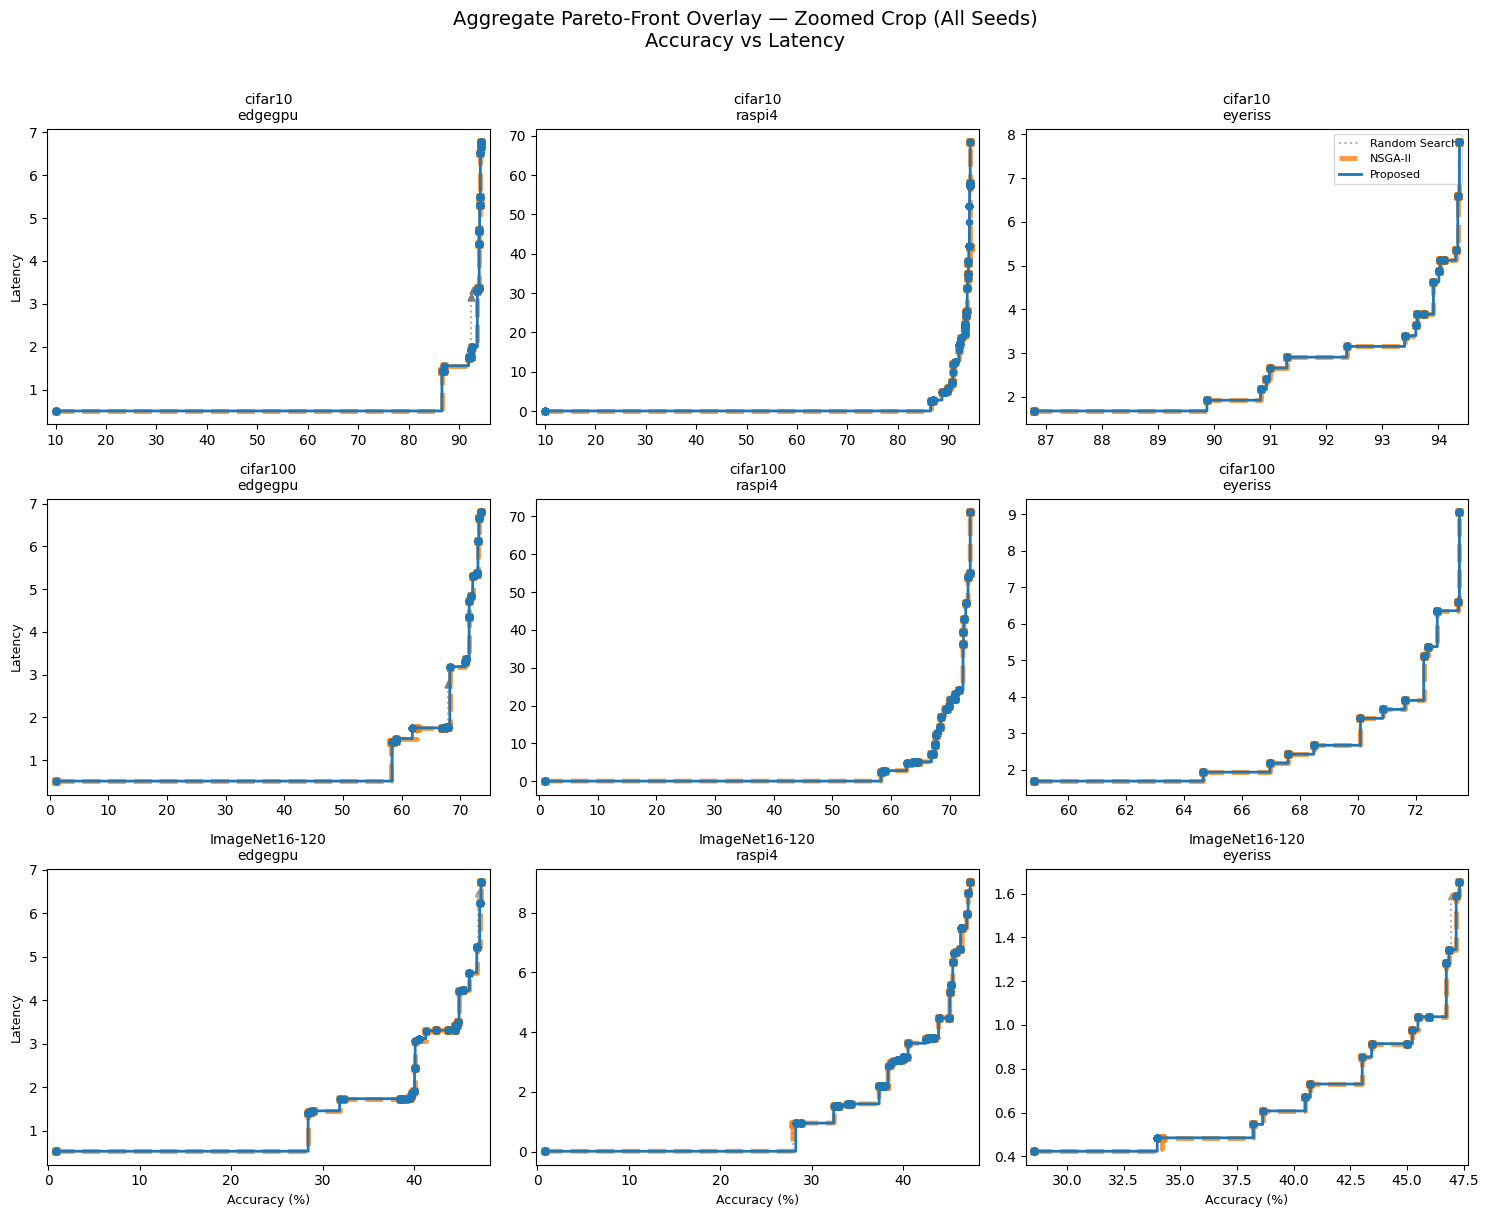

Saved: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/figures/comparison/pareto_overlay_3x3_zoomed.pdf


In [6]:
# ── 3×3 Pareto front overlay — zoomed crop, Notebook-1 style ─────────────────
# • ax.step(where="post") for proper staircase Pareto fronts
# • Explicit zorder:  Proposed=10, NSGA-II=5, Random Search=1
# • Markers drawn separately via ax.scatter() with matching zorder
# • ALGO_STYLES matches Notebook 1: (color, linestyle, marker, lw, zorder, alpha)

from src.analysis.data_loader import aggregate_front  # returns (acc, lat)

ALGO_STYLES = {
    "Proposed":      ("#1f77b4", "-",  "o", 2.0, 10, 1.0),
    "NSGA-II":       ("#ff7f0e", "--", "s", 3.5,  5, 0.8),
    "Random Search": ("#7f7f7f", ":",  "^", 1.5,  1, 0.6),
}
# Keep ALGO_COLORS in sync for any cells that still reference it
ALGO_COLORS = {k: v[0] for k, v in ALGO_STYLES.items()}

fig2, axes2 = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle("Aggregate Pareto-Front Overlay — Zoomed Crop (All Seeds)\nAccuracy vs Latency",
              fontsize=14, y=1.01)

PLOT_ORDER = ["Random Search", "NSGA-II", "Proposed"]   # back-to-front draw order

for r, dataset in enumerate(DATASETS):
    for c, hw in enumerate(HARDWARE):
        ax = axes2[r][c]
        combo = combo_archive_sets(RESULTS_DIR, dataset, hw)
        if not combo:
            ax.set_visible(False)
            continue

        all_acc_pts, all_lat_pts = [], []
        lines_to_draw = []   # defer plotting so limits are set first

        for algo in PLOT_ORDER:
            if algo not in combo:
                continue
            front = aggregate_front(combo[algo])

            if isinstance(front, tuple) and len(front) == 2:
                acc, lat = front
            else:
                front = np.asarray(front)
                if front.size == 0 or front.ndim != 2 or front.shape[1] < 2:
                    continue
                acc, lat = front[:, 0], front[:, 1]

            acc = np.asarray(acc, dtype=float)
            lat = np.asarray(lat, dtype=float)
            if acc.size == 0:
                continue

            # Sort by accuracy for correct step-plot direction
            order = np.argsort(acc)
            acc, lat = acc[order], lat[order]

            all_acc_pts.append(acc)
            all_lat_pts.append(lat)
            lines_to_draw.append((algo, acc, lat))

        if not lines_to_draw:
            ax.set_visible(False)
            continue

        # ── Tight zoomed crop on BOTH axes ────────────────────────────────────
        x_all = np.concatenate(all_acc_pts)
        y_all = np.concatenate(all_lat_pts)
        x_lo, x_hi = x_all.min(), x_all.max()
        y_lo, y_hi = y_all.min(), y_all.max()
        x_range = max(x_hi - x_lo, 1e-9)
        y_range = max(y_hi - y_lo, 1e-9)
        x_pad = max(x_range * 0.02, 0.05)
        y_pad = max(y_range * 0.05, y_range * 0.01)
        ax.set_xlim(x_lo - x_pad, x_hi + x_pad)
        ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

        for algo, acc, lat in lines_to_draw:
            color, ls, mk, lw, zo, al = ALGO_STYLES[algo]
            # Step line
            ax.step(acc, lat,
                    where="post",
                    color=color,
                    linestyle=ls,
                    linewidth=lw,
                    alpha=al,
                    zorder=zo,
                    label=algo)
            # Scatter markers on step corners (zorder one above the line)
            ax.scatter(acc, lat,
                       marker=mk,
                       s=20,
                       color=color,
                       alpha=al,
                       zorder=zo + 1)

        ax.set_title(f"{dataset}\n{hw.replace('_latency', '')}", fontsize=10)
        if c == 0:
            ax.set_ylabel("Latency", fontsize=9)
        if r == 2:
            ax.set_xlabel("Accuracy (%)", fontsize=9)
        if r == 0 and c == 2:
            ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
save_path2 = OUT_DIR / "pareto_overlay_3x3_zoomed.pdf"
plt.savefig(save_path2, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {save_path2}")


## 5. Top-5 Pareto-Optimal Architectures

The architectures below are extracted from the **Aggregate Pareto Front** — the
non-dominated set formed by pooling every solution from all 30 seeds of the
**Proposed (MOEA/D + PSO + SA)** algorithm for each (dataset × hardware) combination.
Pooling across seeds produces a more representative front than any single run and
eliminates run-to-run variance from the reported genotypes.

Each row corresponds to a Pareto-optimal cell genotype: a sequence of 6 operation
choices (one per directed edge in the NAS-Bench-201 cell graph) that lies on the
accuracy/latency trade-off frontier. Architectures are ranked by **accuracy (descending)**.

In [7]:
# ── Top-5 architectures per combo (Proposed runs only) ────────────────────────
for dataset in DATASETS:
    for hw in HARDWARE:
        combo = combo_archive_sets(RESULTS_DIR, dataset, hw)
        proposed_runs = combo.get("Proposed", [])
        if not proposed_runs:
            print(f"[{dataset} × {hw}]  No Proposed runs found.\n")
            continue
        # Limit per-seed archive size to avoid O(N^2)-style memory blowups in best_archs_table
        MAX_POINTS_PER_RUN = 300
        reduced_runs = [
            run[-MAX_POINTS_PER_RUN:] if isinstance(run, list) and len(run) > MAX_POINTS_PER_RUN else run
            for run in proposed_runs
        ]

        try:
            best_archs_table(reduced_runs, label=f"{dataset} × {hw}", n=5)
        except MemoryError:
            print(f"[{dataset} × {hw}] MemoryError in best_archs_table even after reduction; skipped.\n")



  TOP-5 PARETO ARCHITECTURES — cifar10 × edgegpu_latency
     Accuracy (%) Latency (ms)                                                                             Architecture
Rank                                                                                                                   
1           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
2           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
3           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
4           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3
5           94.37       6.7722  nor_conv_3x3 | nor_conv_3x3 | nor_conv_3x3 | skip_connect | nor_conv_1x1 | nor_conv_3x3

  TOP-5 PARETO ARCHITECTURES — cifar10 × raspi4_latency
     Accuracy (%) Latency (ms)               